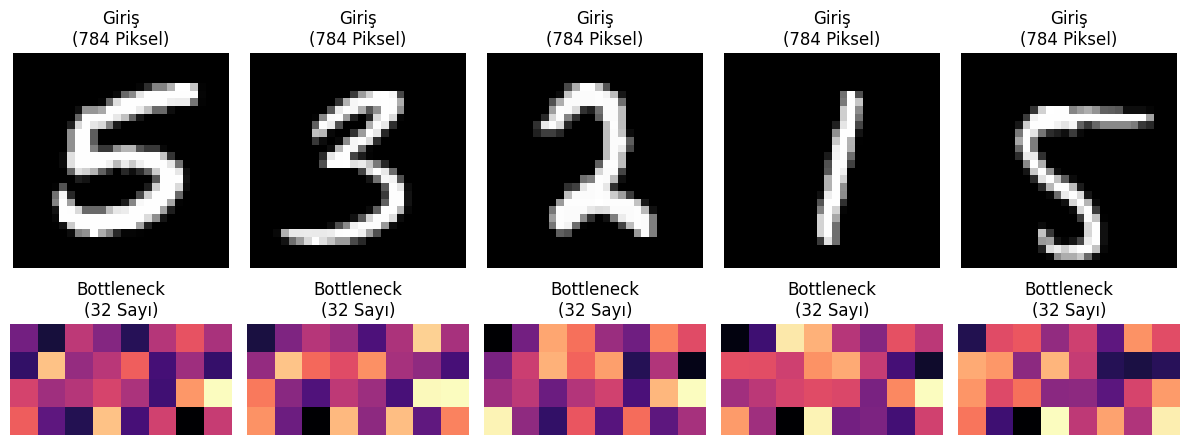

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# 1. HAZIRLIK
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose([transforms.ToTensor()])
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=5, shuffle=True)

# 2. MODEL (Bottleneck Görselleştirme İçin)
class AutoencoderBottleneck(nn.Module):
    def __init__(self):
        super().__init__()
        # 784 -> 32 (Sıkıştırma)
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 32) # Burası Bottleneck!
        )
    def forward(self, x):
        return self.encoder(x.view(-1, 784))

# Modeli oluştur (Eğitilmiş varsayıyoruz, mantığı göstermek için)
model_bottleneck = AutoencoderBottleneck().to(device)

# 3. GÖRSELLEŞTİRME: RESİM VS. MATEMATİKSEL KOD
images, _ = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    latent_codes = model_bottleneck(images)

plt.figure(figsize=(12, 5))
for i in range(5):
    # Üstte Orijinal Resim (784 Piksel)
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].cpu().squeeze(), cmap='gray')
    plt.title(f"Giriş\n(784 Piksel)")
    plt.axis('off')

    # Altta Bottleneck / Latent Space (32 Sayı)
    # 32 sayıyı görselleştirmek için 8x4'lük bir matris yapıyoruz
    plt.subplot(2, 5, i + 6)
    plt.imshow(latent_codes[i].cpu().numpy().reshape(4, 8), cmap='magma')
    plt.title(f"Bottleneck\n(32 Sayı)")
    plt.axis('off')

plt.tight_layout()
plt.show()